In [1]:
print("hello")

hello


In [11]:
from langchain_groq import ChatGroq
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents import create_agent
from langgraph.store.memory import InMemoryStore
from langgraph.utils.config import get_store
from langmem import create_manage_memory_tool
import os
from dotenv import load_dotenv



In [12]:
load_dotenv()

GROQ_API_KEY=os.getenv("GROQ_API_KEY")

In [3]:
def prompt(state):
    """Prepare the messages for the LLM."""
    # Get store from configured contextvar; 
    store = get_store() # Same as that provided to `create_react_agent`
    memories = store.search(
        # Search within the same namespace as the one
        # we've configured for the agent
        ("memories",),
        query=state["messages"][-1].content,
    )
    system_msg = f"""You are a helpful assistant.

## Memories
<memories>
{memories}
</memories>
"""
    return [{"role": "system", "content": system_msg}, *state["messages"]]

In [5]:
embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

d:\Vaibhav_PC\GenAI\Krish_project\InsuranceClaimAgent\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2888.68it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
len(embeddings.embed_query("hello"))

384

In [8]:
store = InMemoryStore(
    index={
        'embed': embeddings,
        'dims': 384
    }   
    )


In [9]:
checkpoint = MemorySaver()

In [13]:
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY
    
)

model.invoke("what is the capital of india")

AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 41, 'total_tokens': 52, 'completion_time': 0.023660243, 'completion_tokens_details': None, 'prompt_time': 0.003689181, 'prompt_tokens_details': None, 'queue_time': 0.054945748, 'total_time': 0.027349424}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9c71-7a2d-7461-947d-2f35b9847e01-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 11, 'total_tokens': 52})

In [15]:
agent= create_agent(
    model= model,
    tools=[create_manage_memory_tool(namespace=("memories",))],
    store=store,
    checkpointer=checkpoint
    
)

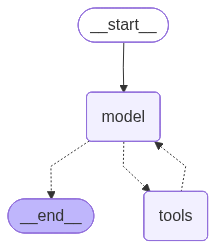

In [16]:
agent

LangMem memory check & cross thread memory check

In [17]:
config = {"configurable": {"thread_id": "thread-a"}}
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "Know which display mode I prefer?"}
        ]
    },
    config=config,
)
print(response["messages"][-1].content)


I don't have any information about your preferred display mode. Please let me know what display mode you prefer, and I'll make sure to update the memory accordingly.


In [19]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "i prefered light mode please remember"}
        ]
    },
    config=config,
)
print(response)
print(response["messages"][-1].content)


{'messages': [HumanMessage(content='Know which display mode I prefer?', additional_kwargs={}, response_metadata={}, id='760dd4d3-f31e-4130-a89c-88b2b07cb757'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4jnbq8r1r', 'function': {'arguments': '{"action":"create","content":"user prefers a specific display mode, but the mode is currently unknown","id":null}', 'name': 'manage_memory'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 451, 'total_tokens': 488, 'completion_time': 0.205856192, 'completion_tokens_details': None, 'prompt_time': 0.048545081, 'prompt_tokens_details': None, 'queue_time': 0.519301407, 'total_time': 0.254401273}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9c75-b811-77a1-a61a-092b12aefa7d-0', tool_calls=[{'name': 'manage_memory', 'args': {'ac

In [20]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "what is my preferred display mode"}
        ]
    },
    config=config,
)

print(response["messages"][-1].content)

You prefer light mode. I have this recorded in your memory with the ID 3405c4dc-6554-4116-82ec-2f9d5da57464.


In [28]:
#check on different thread
new_config = {"configurable": {"thread_id": "thread-c"}}


In [29]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "do you remember which display mode I prefer?"}
        ]
    },
    config=new_config,
)

print(response["messages"][-1].content)

I don't have any information about your preferred display mode. If you'd like to set a preference, please let me know and I'll make sure to remember it for future conversations.


Tool calling in langchain using Groq

In [31]:
from langchain.tools import tool

@tool
def get_uppercase(text: str) -> str:
    """Returns the uppercase version of the input."""
    return text.upper()




In [33]:
up_agent= create_agent(
    model= model,
    tools=[get_uppercase],
    name= "upper_agent",
)


response = up_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "what is my preferred display mode"}
        ]
    },

)

print(response)

{'messages': [HumanMessage(content='what is my preferred display mode', additional_kwargs={}, response_metadata={}, id='077acbaa-fb2e-4a5d-9e35-c157ccba8ad7'), AIMessage(content="I don't have information about your preferred display mode. If you'd like to share it with me or would like some general information about display modes, I'd be happy to help.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 222, 'total_tokens': 260, 'completion_time': 0.136973558, 'completion_tokens_details': None, 'prompt_time': 0.019939008, 'prompt_tokens_details': None, 'queue_time': 0.162352154, 'total_time': 0.156912566}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_4f6d808339', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, name='upper_agent', id='lc_run--019d9f3a-3677-7471-84a8-9e4592253cad-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 222, 'output_to

In [36]:
up_agent= create_agent(
    model= model,
    tools=[get_uppercase],
    name= "upper_agent",
)


response = up_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "make uppercase of 'AI agent'"}
        ]
    },

)

print(response)

{'messages': [HumanMessage(content="make uppercase of 'AI agent'", additional_kwargs={}, response_metadata={}, id='a7e47b25-2d75-43dd-a5dd-b5dcc83ed9ae'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '02mre1b3y', 'function': {'arguments': '{"text":"AI agent"}', 'name': 'get_uppercase'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 223, 'total_tokens': 239, 'completion_time': 0.038439695, 'completion_tokens_details': None, 'prompt_time': 0.045367642, 'prompt_tokens_details': None, 'queue_time': 0.176064405, 'total_time': 0.083807337}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, name='upper_agent', id='lc_run--019d9f3c-92e5-7fb3-b9e3-25e58f744a77-0', tool_calls=[{'name': 'get_uppercase', 'args': {'text': 'AI agent'}, 'id': '02mre1b3y', 'type': 'tool_call'}], invalid_tool_calls=